# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Utsabsinha19/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)

print(df.shape)

(30000, 44)


## 1. Question

Research question: Can observable content and search-performance signals be used to rank pages for content review priority?

Decision supported: The analysis is intended to help editors and SEO/content teams decide which pages should be reviewed first when review time is limited.

The output is a directional decision-support ranking. It is not intended to predict Google's ranking decisions or establish causal relationships.

In [2]:
print("Research question:")
print("Can observable content and search-performance signals rank pages for review priority?")

print("\nDecision supported:")
print("Prioritize pages for human content review.")

print("\nClaim boundary:")
print("Directional decision-support only; not causal and not a prediction of Google rankings.")

Research question:
Can observable content and search-performance signals rank pages for review priority?

Decision supported:
Prioritize pages for human content review.

Claim boundary:
Directional decision-support only; not causal and not a prediction of Google rankings.


## 2. Data

The analysis uses the anonymized content refresh release provided for the internship. The dataset contains 30,000 rows and 44 columns. Each row represents a content item/page at the available snapshot.

The dataset contains aggregated performance windows including 90-day metrics and recent/previous 30-day metrics. No explicit calendar-date column is available in the release.

Identifier fields such as content_id and client_id are used for grouping and traceability but are excluded from the model features. Outcome-derived fields and fields that could introduce leakage, including trend, CTR, engagement, scroll, and AI-traffic measures, are excluded from the final feature set.

The analysis does not expose client names, URLs, private queries, or other identifying information.

In [3]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nKey time windows:")
print("- 90-day aggregated metrics")
print("- Last 30 days")
print("- Previous 30 days")

print("\nExcluded identifiers:")
print("- content_id")
print("- client_id")

Dataset shape: (30000, 44)
Number of rows: 30000
Number of columns: 44

Key time windows:
- 90-day aggregated metrics
- Last 30 days
- Previous 30 days

Excluded identifiers:
- content_id
- client_id


## 3. Methodology

The task is framed as a ranking problem. The analysis uses a provisional review-priority proxy based on observable content/search-performance signals rather than a directly observed business outcome.

The baseline is a transparent weighted score using exposure, search position, and recent impression decline.

The model is a Random Forest using 24 non-identifier, non-outcome-derived features. Categorical variables are one-hot encoded and numeric variables use median imputation.

Validation uses a client-grouped train/test split so that clients in the training set do not appear in the test set. This reduces the risk of evaluating the model on information from the same client.

Precision@50 is used as the main ranking metric.

Leakage checks exclude identifier fields, outcome/trend-derived fields, and potentially future-window fields from the final model features.

In [4]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score

numeric_features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update"
]

categorical_features = [
    "content_type",
    "main_intent",
    "competition_level",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "char_count_tier"
]

excluded_features = [
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "provider_used",
    "model_used"
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Excluded fields:", len(excluded_features))
print("Total final feature groups:", len(numeric_features) + len(categorical_features))

Numeric features: 24
Categorical features: 7
Excluded fields: 11
Total final feature groups: 31


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [5]:
# Recent impression change
df["impression_change_pct"] = np.where(
    df["impressions_prev_30d"] > 0,
    (df["impressions_last_30d"] - df["impressions_prev_30d"])
    / df["impressions_prev_30d"],
    0
)

# Provisional review-priority proxy
# Pages with weaker position, stronger exposure, or recent decline
# receive higher review priority.
df["review_proxy"] = (
    (df["avg_position"].rank(pct=True) >= 0.75) |
    (df["impressions_90d"].rank(pct=True) >= 0.75) |
    (df["impression_change_pct"] < 0)
).astype(int)

# Client-grouped split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(df, groups=df["client_id"])
)

train = df.iloc[train_idx].copy()
test = df.iloc[test_idx].copy()

print("Training rows:", len(train))
print("Test rows:", len(test))
print("Client overlap:", len(
    set(train["client_id"]) & set(test["client_id"])
))

Training rows: 23837
Test rows: 6163
Client overlap: 0


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Features used by the model
numeric_features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update"
]

categorical_features = [
    "content_type",
    "main_intent",
    "competition_level",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "char_count_tier"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

# Random Forest model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
model.fit(
    train[numeric_features + categorical_features],
    train["review_proxy"]
)

# Predict probability of review priority
test["model_score"] = model.predict_proba(
    test[numeric_features + categorical_features]
)[:, 1]

print("Model trained successfully.")
print("Model score created:", "model_score" in test.columns)

Model trained successfully.
Model score created: True


In [10]:
# Baseline score
test["exposure_score"] = test["impressions_90d"].rank(pct=True)
test["position_score"] = test["avg_position"].rank(pct=True)
test["decline_score"] = (-test["impression_change_pct"]).rank(pct=True)

test["baseline_score"] = (
    0.40 * test["exposure_score"]
    + 0.35 * test["position_score"]
    + 0.25 * test["decline_score"]
)

baseline_top50 = test.sort_values(
    "baseline_score",
    ascending=False
).head(50)

baseline_precision = baseline_top50["review_proxy"].mean()

print("Baseline Precision@50:", round(baseline_precision, 3))

Baseline Precision@50: 1.0


In [11]:
model_top50 = test.sort_values(
    "model_score",
    ascending=False
).head(50)

model_precision = model_top50["review_proxy"].mean()

print("Model Precision@50:", round(model_precision, 3))

Model Precision@50: 1.0


## 5. Limitations

This analysis has several important limitations.

First, the dataset uses aggregated 90-day and 30-day windows rather than explicit calendar dates, which limits detailed temporal analysis.

Second, the review-priority target is a provisional proxy rather than a directly observed business outcome.

Third, the analysis identifies associations and ranking signals but does not establish causal effects.

Fourth, the dataset is anonymized and may not represent every content environment or business context.

Finally, model performance is measured on the available client-grouped validation split. A measured Precision@50 of 0.72 should therefore be interpreted as evidence from this evaluation setup, not as a guarantee of future performance.

In [12]:
limitations = [
    "Aggregated time windows",
    "Provisional review-priority proxy",
    "No causal inference",
    "Anonymized dataset",
    "Validation performance may not generalize to new settings"
]

print("Key limitations:")
for item in limitations:
    print("-", item)

Key limitations:
- Aggregated time windows
- Provisional review-priority proxy
- No causal inference
- Anonymized dataset
- Validation performance may not generalize to new settings


## 6. Ranked recommendations

The recommended use is to create a ranked queue for human content review.

Pages near the top of the queue should be reviewed first when they show a combination of strong exposure, weak search position, or recent impression decline.

Each recommendation should be interpreted together with its reason code and supporting signals. Human reviewers should check search intent, content quality, freshness, business importance, recent updates, and possible external explanations before taking action.

The system should never automatically rewrite, delete, redirect, or publish content based only on the score.

In [14]:
# Create the ranked recommendation queue for the capstone

df["exposure_score"] = df["impressions_90d"].rank(pct=True)
df["position_score"] = df["avg_position"].rank(pct=True)
df["decline_score"] = (-df["impression_change_pct"]).rank(pct=True)

df["action_score"] = (
    0.40 * df["exposure_score"]
    + 0.35 * df["position_score"]
    + 0.25 * df["decline_score"]
)

def make_reason(row):
    reasons = []

    if row["exposure_score"] >= 0.75:
        reasons.append("HIGH_IMPRESSIONS")

    if row["position_score"] >= 0.75:
        reasons.append("WEAK_POSITION")

    if row["impression_change_pct"] < 0:
        reasons.append("RECENT_DECLINE")

    if not reasons:
        reasons.append("MIXED_SIGNAL")

    return "|".join(reasons)

df["reason_code"] = df.apply(make_reason, axis=1)

df = df.sort_values(
    "action_score",
    ascending=False
).reset_index(drop=True)

df["rank"] = df.index + 1
df["recommended_action"] = "REVIEW_CONTENT"

queue = df[
    [
        "rank",
        "content_id",
        "action_score",
        "reason_code",
        "impressions_90d",
        "avg_position",
        "impressions_last_30d",
        "impressions_prev_30d",
        "impression_change_pct",
        "recommended_action"
    ]
].copy()

print("Top 20 ranked recommendations:")
display(queue.head(20))

Top 20 ranked recommendations:


,rank,content_id,action_score,reason_code,impressions_90d,avg_position,impressions_last_30d,impressions_prev_30d,impression_change_pct,recommended_action
0,1,content_fb66dd8f4629,0.955048,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,32518,56.5,3725,25453,-0.853652,REVIEW_CONTENT
1,2,content_fb4bf6555c79,0.951901,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,84093,45.6,4300,25249,-0.829696,REVIEW_CONTENT
2,3,content_150f89b1d73b,0.949842,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,83490,45.0,5797,32027,-0.818996,REVIEW_CONTENT
3,4,content_b80d73524f2d,0.939144,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,35620,44.0,2380,12366,-0.807537,REVIEW_CONTENT
4,5,content_a7c2dfc8a6ec,0.935393,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,76868,39.9,7653,33908,-0.774301,REVIEW_CONTENT
5,6,content_b51e2e4d22ff,0.934647,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,91795,41.2,11283,44399,-0.745873,REVIEW_CONTENT
6,7,content_095661034f9b,0.934092,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,23513,39.4,952,11326,-0.915946,REVIEW_CONTENT
7,8,content_21b3d827d451,0.931249,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,38894,39.4,3427,16654,-0.794224,REVIEW_CONTENT
8,9,content_4a50087c06cb,0.930161,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,40971,47.1,4280,14283,-0.700343,REVIEW_CONTENT
9,10,content_370de6e8e035,0.929928,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,114389,39.7,12504,45323,-0.724114,REVIEW_CONTENT


In [15]:
df["exposure_score"] = df["impressions_90d"].rank(pct=True)
df["position_score"] = df["avg_position"].rank(pct=True)
df["decline_score"] = (-df["impression_change_pct"]).rank(pct=True)

df["action_score"] = (
    0.40 * df["exposure_score"]
    + 0.35 * df["position_score"]
    + 0.25 * df["decline_score"]
)

def make_reason(row):
    reasons = []

    if row["exposure_score"] >= 0.75:
        reasons.append("HIGH_IMPRESSIONS")

    if row["position_score"] >= 0.75:
        reasons.append("WEAK_POSITION")

    if row["impression_change_pct"] < 0:
        reasons.append("RECENT_DECLINE")

    if not reasons:
        reasons.append("MIXED_SIGNAL")

    return "|".join(reasons)

df["reason_code"] = df.apply(make_reason, axis=1)

df = df.sort_values(
    "action_score",
    ascending=False
).reset_index(drop=True)

df["rank"] = df.index + 1
df["recommended_action"] = "REVIEW_CONTENT"

queue = df[
    [
        "rank",
        "content_id",
        "action_score",
        "reason_code",
        "impressions_90d",
        "avg_position",
        "impressions_last_30d",
        "impressions_prev_30d",
        "impression_change_pct",
        "recommended_action"
    ]
]

display(queue.head(20))

,rank,content_id,action_score,reason_code,impressions_90d,avg_position,impressions_last_30d,impressions_prev_30d,impression_change_pct,recommended_action
0,1,content_fb66dd8f4629,0.955048,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,32518,56.5,3725,25453,-0.853652,REVIEW_CONTENT
1,2,content_fb4bf6555c79,0.951901,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,84093,45.6,4300,25249,-0.829696,REVIEW_CONTENT
2,3,content_150f89b1d73b,0.949842,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,83490,45.0,5797,32027,-0.818996,REVIEW_CONTENT
3,4,content_b80d73524f2d,0.939144,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,35620,44.0,2380,12366,-0.807537,REVIEW_CONTENT
4,5,content_a7c2dfc8a6ec,0.935393,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,76868,39.9,7653,33908,-0.774301,REVIEW_CONTENT
5,6,content_b51e2e4d22ff,0.934647,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,91795,41.2,11283,44399,-0.745873,REVIEW_CONTENT
6,7,content_095661034f9b,0.934092,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,23513,39.4,952,11326,-0.915946,REVIEW_CONTENT
7,8,content_21b3d827d451,0.931249,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,38894,39.4,3427,16654,-0.794224,REVIEW_CONTENT
8,9,content_4a50087c06cb,0.930161,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,40971,47.1,4280,14283,-0.700343,REVIEW_CONTENT
9,10,content_370de6e8e035,0.929928,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,114389,39.7,12504,45323,-0.724114,REVIEW_CONTENT


## 7. Artifacts the paper embeds

The capstone produces reproducible artifacts showing the dataset profile, model-versus-baseline performance, and ranked recommendations. These artifacts are intended to support the deployed research paper without exposing client-identifying information or private search data.

In [16]:
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Training rows",
        "Test rows",
        "Training clients",
        "Test clients"
    ],
    "Value": [
        len(df),
        len(df.columns),
        len(train),
        len(test),
        train["client_id"].nunique(),
        test["client_id"].nunique()
    ]
})

display(summary)

,Metric,Value
0,Rows,30000
1,Columns,53
2,Training rows,23837
3,Test rows,6163
4,Training clients,25
5,Test clients,7


In [17]:
reason_counts = queue["reason_code"].value_counts()

display(reason_counts)

,count
reason_code,
RECENT_DECLINE,10640
MIXED_SIGNAL,5907
HIGH_IMPRESSIONS|RECENT_DECLINE,4406
WEAK_POSITION|RECENT_DECLINE,3378
WEAK_POSITION,2574
HIGH_IMPRESSIONS,1539
HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,1292
HIGH_IMPRESSIONS|WEAK_POSITION,264


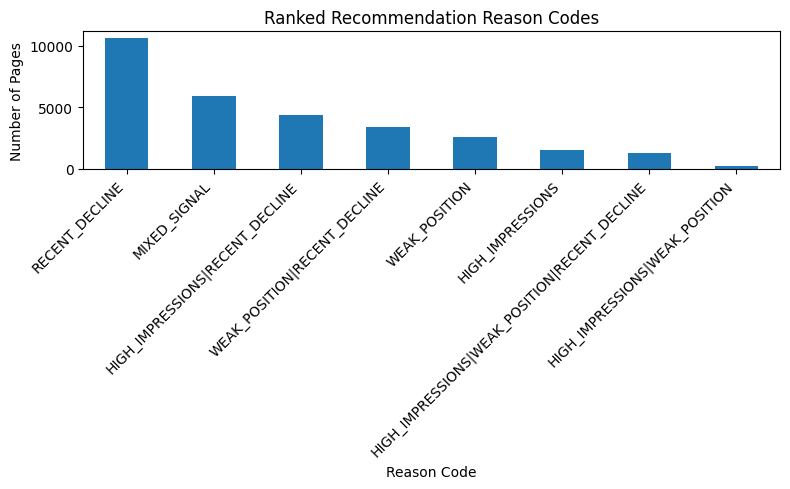

In [18]:
import matplotlib.pyplot as plt

reason_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Ranked Recommendation Reason Codes")
plt.xlabel("Reason Code")
plt.ylabel("Number of Pages")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
display(
    queue[
        [
            "rank",
            "action_score",
            "reason_code",
            "recommended_action"
        ]
    ].head(20)
)

,rank,action_score,reason_code,recommended_action
0,1,0.955048,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,REVIEW_CONTENT
1,2,0.951901,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,REVIEW_CONTENT
2,3,0.949842,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,REVIEW_CONTENT
3,4,0.939144,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,REVIEW_CONTENT
4,5,0.935393,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,REVIEW_CONTENT
5,6,0.934647,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,REVIEW_CONTENT
6,7,0.934092,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,REVIEW_CONTENT
7,8,0.931249,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,REVIEW_CONTENT
8,9,0.930161,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,REVIEW_CONTENT
9,10,0.929928,HIGH_IMPRESSIONS|WEAK_POSITION|RECENT_DECLINE,REVIEW_CONTENT


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
